Feature Engineering for Geometric Analysis
✓ Found cleaned data at: c:\Users\nate\Documents\GitHub\Air-Quality-Analysis\data\processed\air_quality_cleaned.csv

Loading cleaned data...
✓ Loaded data: (9357, 12)
Date range: 2004-03-10 18:00:00 to 2005-04-04 14:00:00

Applying Feature Engineering

Creating temporal features...
✓ Created 17 temporal features

Temporal Features Created:
   1. hour
   2. day
   3. month
   4. year
   5. dayofweek
   6. dayofyear
   7. week
   8. hour_sin
   9. hour_cos
  10. dow_sin
  11. dow_cos
  12. month_sin
  13. month_cos
  14. is_night
  15. is_morning
  16. is_afternoon
  17. is_evening
  18. is_weekend
  19. season

Creating pollution features...
Found 12 potential pollutant columns
  Created ratio: CO(GT)_to_NOx(GT)
  Created rate features for: CO(GT)
  Created rate features for: PT08.S1(CO)
  Created rate features for: NOx(GT)
  Created rolling stats for: CO(GT)
  Created rolling stats for: PT08.S1(CO)
  Created lag features for: CO(GT)
  Created 

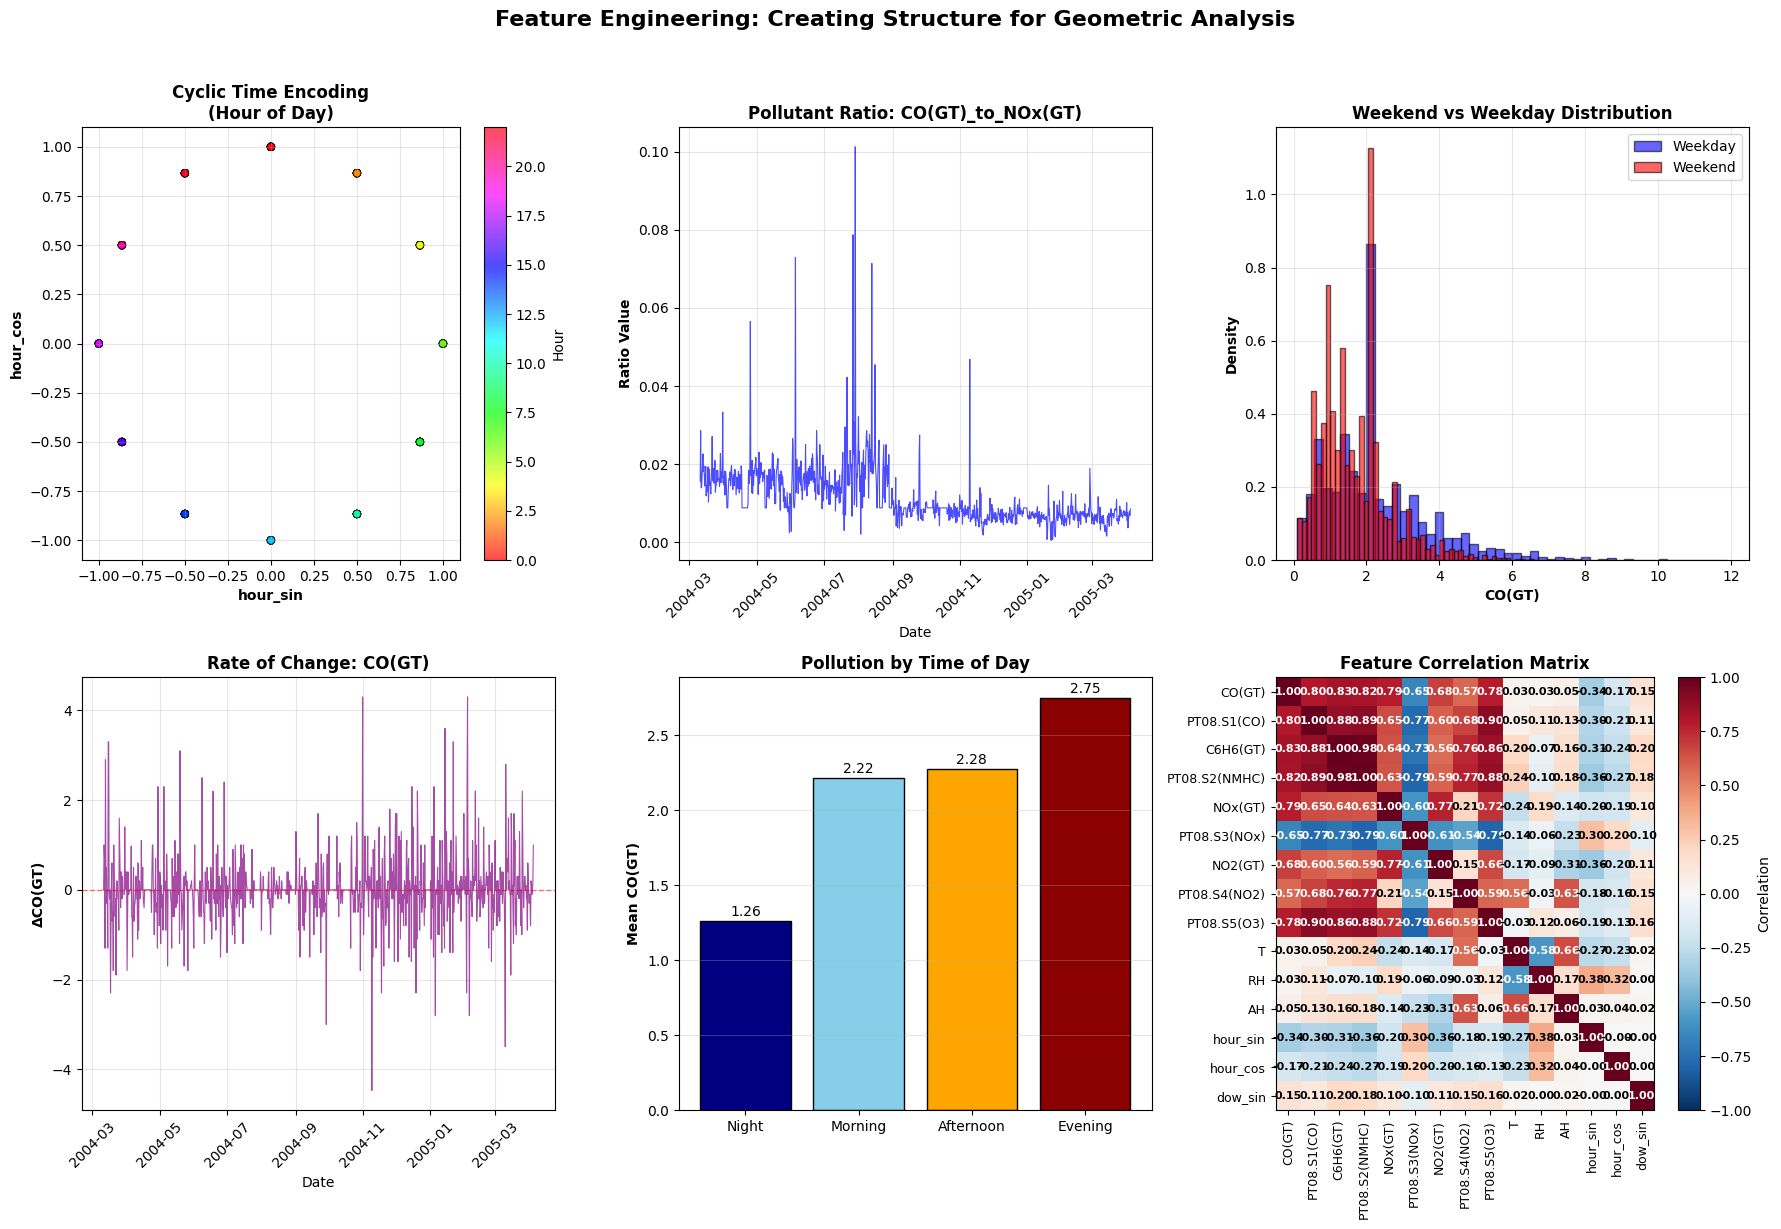


Saving Results
✓ Feature matrix saved to ../data/processed/feature_matrix.csv
  Shape: (9357, 51)
  Size: 4125.7 KB
✓ Feature matrix saved as pickle to ../data/processed/feature_matrix.pkl
  Size: 3521.4 KB
✓ Feature names saved to ../data/processed/feature_names.txt

GEOMETRIC INTERPRETATION OF ENGINEERED FEATURES:

1. Cyclic Encodings (sin/cos):
   • Preserve circular geometry of time
   • Euclidean distance between 23:59 and 00:01 is small
   • Avoids discontinuity at midnight

2. Pollutant Ratios:
   • Create scale-invariant features
   • Cosine distance on ratios finds similar combustion regimes
   • Robust to absolute concentration changes

3. Time-of-Day Indicators:
   • Create categorical structure in feature space
   • May form natural clusters for similar times
   • Useful for time-aware distance metrics

4. Rate-of-Change Features:
   • Capture dynamical system behavior
   • Important for time-series distance metrics (DTW)
   • Can identify rapid pollution events

5. Rollin

In [2]:
# Feature Engineering for Geometric Analysis.
#
# **Goal**: Create features that expose meaningful structure for distance metrics.

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

print("="*60)
print("Feature Engineering for Geometric Analysis")
print("="*60)

# First, check if cleaned data exists
cleaned_data_paths = [
    '../data/processed/air_quality_cleaned.csv',
    'data/processed/air_quality_cleaned.csv',
    'air_quality_cleaned.csv'
]

data_path = None
for path in cleaned_data_paths:
    if os.path.exists(path):
        data_path = path
        print(f"✓ Found cleaned data at: {os.path.abspath(path)}")
        break

if data_path is None:
    print("\n❌ Cleaned data not found. Please run the cleaning script first.")
    print("Expected locations:")
    for path in cleaned_data_paths:
        print(f"  - {path}")
    exit()

# Load cleaned data
print("\nLoading cleaned data...")
try:
    df_clean = pd.read_csv(data_path, index_col='datetime', parse_dates=True)
    print(f"✓ Loaded data: {df_clean.shape}")
    print(f"Date range: {df_clean.index.min()} to {df_clean.index.max()}")
except Exception as e:
    print(f"❌ Error loading data: {e}")
    print("\nTrying alternative loading method...")
    df_clean = pd.read_csv(data_path)
    # Try to find datetime column
    datetime_col = None
    for col in df_clean.columns:
        if 'date' in col.lower() or 'time' in col.lower():
            datetime_col = col
            break

    if datetime_col:
        df_clean[datetime_col] = pd.to_datetime(df_clean[datetime_col], errors='coerce')
        df_clean.set_index(datetime_col, inplace=True)
        df_clean = df_clean.sort_index()
        print(f"✓ Loaded using column '{datetime_col}' as index")
    else:
        print("⚠ No datetime column found, using default index")

# Feature engineering functions
def create_temporal_features(df):
    """Create temporal features from datetime index"""
    print("\nCreating temporal features...")
    df_temp = df.copy()

    if isinstance(df_temp.index, pd.DatetimeIndex):
        # Basic time features
        df_temp['hour'] = df_temp.index.hour
        df_temp['day'] = df_temp.index.day
        df_temp['month'] = df_temp.index.month
        df_temp['year'] = df_temp.index.year
        df_temp['dayofweek'] = df_temp.index.dayofweek  # Monday=0, Sunday=6
        df_temp['dayofyear'] = df_temp.index.dayofyear
        df_temp['week'] = df_temp.index.isocalendar().week

        # Cyclic encoding for hour (preserves circular nature)
        df_temp['hour_sin'] = np.sin(2 * np.pi * df_temp['hour'] / 24)
        df_temp['hour_cos'] = np.cos(2 * np.pi * df_temp['hour'] / 24)

        # Cyclic encoding for day of week
        df_temp['dow_sin'] = np.sin(2 * np.pi * df_temp['dayofweek'] / 7)
        df_temp['dow_cos'] = np.cos(2 * np.pi * df_temp['dayofweek'] / 7)

        # Cyclic encoding for month
        df_temp['month_sin'] = np.sin(2 * np.pi * df_temp['month'] / 12)
        df_temp['month_cos'] = np.cos(2 * np.pi * df_temp['month'] / 12)

        # Time of day categories
        df_temp['is_night'] = ((df_temp['hour'] >= 0) & (df_temp['hour'] < 6)).astype(int)
        df_temp['is_morning'] = ((df_temp['hour'] >= 6) & (df_temp['hour'] < 12)).astype(int)
        df_temp['is_afternoon'] = ((df_temp['hour'] >= 12) & (df_temp['hour'] < 18)).astype(int)
        df_temp['is_evening'] = ((df_temp['hour'] >= 18) & (df_temp['hour'] < 24)).astype(int)

        # Weekend indicator
        df_temp['is_weekend'] = (df_temp['dayofweek'] >= 5).astype(int)

        # Season (approximate)
        df_temp['season'] = (df_temp['month'] % 12 + 3) // 3
        # Spring=1, Summer=2, Fall=3, Winter=4

        print(f"✓ Created {sum(['hour' in col or 'day' in col or 'month' in col
                               or 'year' in col or 'week' in col or 'season' in col
                               or 'is_' in col for col in df_temp.columns])} temporal features")
    else:
        print("⚠ No datetime index found, skipping temporal features")

    return df_temp

def create_pollution_features(df):
    """Create pollution-specific features"""
    print("\nCreating pollution features...")
    df_feat = df.copy()

    # List of possible pollutant column patterns
    pollutant_patterns = ['CO', 'NO', 'NOx', 'NO2', 'O3', 'SO2', 'PM', 'BEN', 'RH', 'TEMP']

    # Find actual pollutant columns
    pollutant_cols = []
    for col in df_feat.columns:
        for pattern in pollutant_patterns:
            if pattern in col.upper():
                pollutant_cols.append(col)
                break

    print(f"Found {len(pollutant_cols)} potential pollutant columns")

    if pollutant_cols:
        # 1. Ratios between pollutants
        co_cols = [col for col in pollutant_cols if 'CO' in col.upper()]
        nox_cols = [col for col in pollutant_cols if 'NO' in col.upper()]

        if co_cols and nox_cols:
            co_col = co_cols[0]
            nox_col = nox_cols[0]
            df_feat[f'{co_col}_to_{nox_col}'] = df_feat[co_col] / (df_feat[nox_col] + 1e-6)  # Avoid division by zero
            print(f"  Created ratio: {co_col}_to_{nox_col}")

        # 2. Rate of change (1-hour difference)
        for col in pollutant_cols[:3]:  # Limit to first 3 to avoid too many features
            df_feat[f'{col}_diff'] = df_feat[col].diff()
            df_feat[f'{col}_diff_abs'] = df_feat[col].diff().abs()
            print(f"  Created rate features for: {col}")

        # 3. Rolling statistics (captures trends)
        for col in pollutant_cols[:2]:  # Limit to first 2
            df_feat[f'{col}_rolling_mean_6h'] = df_feat[col].rolling(window=6, min_periods=1).mean()
            df_feat[f'{col}_rolling_std_6h'] = df_feat[col].rolling(window=6, min_periods=1).std()
            print(f"  Created rolling stats for: {col}")

        # 4. Lag features
        for col in pollutant_cols[:2]:
            for lag in [1, 3, 6]:  # 1, 3, and 6 hour lags
                df_feat[f'{col}_lag_{lag}'] = df_feat[col].shift(lag)
            print(f"  Created lag features for: {col}")

        # 5. Interaction features (if we have multiple pollutants)
        if len(pollutant_cols) >= 2:
            col1, col2 = pollutant_cols[0], pollutant_cols[1]
            df_feat[f'{col1}_times_{col2}'] = df_feat[col1] * df_feat[col2]
            df_feat[f'{col1}_plus_{col2}'] = df_feat[col1] + df_feat[col2]
            print(f"  Created interaction between {col1} and {col2}")

    # 6. Overall pollution index (simple average of normalized pollutants)
    if pollutant_cols:
        # Normalize each pollutant
        normalized = pd.DataFrame()
        for col in pollutant_cols:
            if df_feat[col].std() > 0:  # Avoid division by zero
                normalized[col] = (df_feat[col] - df_feat[col].mean()) / df_feat[col].std()

        if not normalized.empty:
            df_feat['pollution_index'] = normalized.mean(axis=1)
            print(f"  Created pollution index from {len(normalized.columns)} pollutants")

    print(f"✓ Created {sum(['_diff' in col or '_rolling' in col or '_lag' in col
                           or '_to_' in col or '_times_' in col or '_plus_' in col
                           or 'pollution_index' in col for col in df_feat.columns])} pollution features")

    return df_feat

def get_feature_matrix(df):
    """Extract feature matrix and names"""
    # Remove any remaining NaN values
    df_features = df.copy()

    # Fill any remaining NaNs with column means
    for col in df_features.columns:
        if df_features[col].isnull().sum() > 0:
            df_features[col] = df_features[col].fillna(df_features[col].mean())

    # Get feature names
    feature_names = df_features.columns.tolist()

    # Return both the DataFrame and the names
    return df_features, feature_names

# Apply feature engineering
print("\n" + "="*60)
print("Applying Feature Engineering")
print("="*60)

# Step 1: Create temporal features
df_temp = create_temporal_features(df_clean)

# Identify temporal features created
original_cols = set(df_clean.columns)
temporal_cols = [col for col in df_temp.columns if col not in original_cols]

if temporal_cols:
    print("\nTemporal Features Created:")
    for i, col in enumerate(temporal_cols):
        print(f"  {i+1:2d}. {col}")
else:
    print("\n⚠ No temporal features created (check datetime index)")

# Step 2: Create pollution features
df_feat = create_pollution_features(df_temp)

# Identify pollution features created
temp_cols = set(df_temp.columns)
pollution_cols = [col for col in df_feat.columns if col not in temp_cols]

if pollution_cols:
    print("\nPollution Features Created:")
    for i, col in enumerate(pollution_cols):
        print(f"  {i+1:2d}. {col}")
else:
    print("\n⚠ No pollution features created")

# Step 3: Get complete feature matrix
print("\nCreating final feature matrix...")
X_features, feature_names = get_feature_matrix(df_feat)

print(f"\n🎯 Final Feature Matrix Shape: {X_features.shape}")
print(f"Total features: {len(feature_names)}")

# Show feature categories
print("\n" + "="*60)
print("Feature Categories:")
print("="*60)

# Categorize features
feature_categories = {
    'Original': [col for col in feature_names if col in original_cols],
    'Temporal': temporal_cols,
    'Pollution': pollution_cols
}

for category, features in feature_categories.items():
    if features:
        print(f"\n{category} Features ({len(features)}):")
        for i, feature in enumerate(features[:10]):  # Show first 10
            print(f"  {i+1:2d}. {feature}")
        if len(features) > 10:
            print(f"  ... and {len(features) - 10} more")

# Create output directories
os.makedirs('../outputs/figures', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

# Visualizations
print("\n" + "="*60)
print("Creating Visualizations")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Cyclic time features
ax1 = axes[0, 0]
if 'hour_sin' in X_features.columns and 'hour_cos' in X_features.columns:
    # Sample every 50th point for clarity
    sample_idx = slice(None, None, 50)
    scatter = ax1.scatter(X_features['hour_sin'].iloc[sample_idx],
                         X_features['hour_cos'].iloc[sample_idx],
                         c=X_features.index.hour[sample_idx],
                         cmap='hsv', alpha=0.7, s=30, edgecolor='k', linewidth=0.5)
    ax1.set_xlabel('hour_sin', fontweight='bold')
    ax1.set_ylabel('hour_cos', fontweight='bold')
    ax1.set_title('Cyclic Time Encoding\n(Hour of Day)', fontweight='bold', fontsize=12)
    ax1.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax1, label='Hour')
else:
    ax1.text(0.5, 0.5, 'Cyclic features not available',
             ha='center', va='center', transform=ax1.transAxes, fontsize=12)
    ax1.axis('off')

# 2. Pollutant ratios
ax2 = axes[0, 1]
# Find a ratio feature
ratio_cols = [col for col in X_features.columns if '_to_' in col or 'ratio' in col.lower()]
if ratio_cols:
    ratio_col = ratio_cols[0]
    # Take every 10th point for cleaner plot
    sample_data = X_features[ratio_col].iloc[::10]
    ax2.plot(sample_data.index, sample_data.values, 'b-', linewidth=0.8, alpha=0.7)
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Ratio Value', fontweight='bold')
    ax2.set_title(f'Pollutant Ratio: {ratio_col}', fontweight='bold', fontsize=12)
    ax2.grid(True, alpha=0.3)
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
else:
    # Find any pollutant column
    pollutant_cols = [col for col in X_features.columns if any(p in col.upper() for p in ['CO', 'NO', 'O3', 'PM'])]
    if pollutant_cols:
        sample_col = pollutant_cols[0]
        sample_data = X_features[sample_col].iloc[::10]
        ax2.plot(sample_data.index, sample_data.values, 'g-', linewidth=0.8, alpha=0.7)
        ax2.set_xlabel('Date')
        ax2.set_ylabel('Concentration', fontweight='bold')
        ax2.set_title(f'Pollutant: {sample_col}', fontweight='bold', fontsize=12)
        ax2.grid(True, alpha=0.3)
        plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
    else:
        ax2.text(0.5, 0.5, 'No pollutant data available',
                 ha='center', va='center', transform=ax2.transAxes, fontsize=12)
        ax2.axis('off')

# 3. Weekend vs weekday
ax3 = axes[0, 2]
if 'is_weekend' in X_features.columns:
    # Find a numeric column for comparison
    numeric_cols = X_features.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        compare_col = numeric_cols[0]

        weekend_data = X_features[X_features['is_weekend'] == 1][compare_col].dropna()
        weekday_data = X_features[X_features['is_weekend'] == 0][compare_col].dropna()

        if len(weekend_data) > 0 and len(weekday_data) > 0:
            ax3.hist(weekday_data, bins=50, alpha=0.6, label='Weekday',
                    density=True, color='blue', edgecolor='black')
            ax3.hist(weekend_data, bins=50, alpha=0.6, label='Weekend',
                    density=True, color='red', edgecolor='black')
            ax3.set_xlabel(compare_col, fontweight='bold')
            ax3.set_ylabel('Density', fontweight='bold')
            ax3.set_title('Weekend vs Weekday Distribution', fontweight='bold', fontsize=12)
            ax3.legend()
            ax3.grid(True, alpha=0.3)
        else:
            ax3.text(0.5, 0.5, 'Insufficient data\nfor weekend comparison',
                     ha='center', va='center', transform=ax3.transAxes, fontsize=12)
            ax3.axis('off')
    else:
        ax3.text(0.5, 0.5, 'No numeric data available',
                 ha='center', va='center', transform=ax3.transAxes, fontsize=12)
        ax3.axis('off')
else:
    ax3.text(0.5, 0.5, 'Weekend feature not available',
             ha='center', va='center', transform=ax3.transAxes, fontsize=12)
    ax3.axis('off')

# 4. Rate of change
ax4 = axes[1, 0]
# Find a diff feature
diff_cols = [col for col in X_features.columns if '_diff' in col and '_abs' not in col]
if diff_cols:
    diff_col = diff_cols[0]
    # Get base column name
    base_col = diff_col.replace('_diff', '')

    # Plot rate of change
    sample_data = X_features[diff_col].iloc[::10]
    ax4.plot(sample_data.index, sample_data.values, 'purple', linewidth=0.8, alpha=0.7)
    ax4.axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=1)
    ax4.set_xlabel('Date')
    ax4.set_ylabel(f'Δ{base_col}', fontweight='bold')
    ax4.set_title(f'Rate of Change: {base_col}', fontweight='bold', fontsize=12)
    ax4.grid(True, alpha=0.3)
    plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45)
else:
    ax4.text(0.5, 0.5, 'Rate of change features\nnot available',
             ha='center', va='center', transform=ax4.transAxes, fontsize=12)
    ax4.axis('off')

# 5. Time of day categories
ax5 = axes[1, 1]
time_cat_cols = ['is_night', 'is_morning', 'is_afternoon', 'is_evening']
if all(col in X_features.columns for col in time_cat_cols):
    # Find a numeric column to compare
    numeric_cols = X_features.select_dtypes(include=[np.number]).columns
    numeric_cols = [col for col in numeric_cols if col not in time_cat_cols and col != 'is_weekend']

    if numeric_cols:
        compare_col = numeric_cols[0]
        time_labels = ['Night', 'Morning', 'Afternoon', 'Evening']
        time_means = []

        for col in time_cat_cols:
            mean_val = X_features[X_features[col] == 1][compare_col].mean()
            time_means.append(mean_val if not pd.isna(mean_val) else 0)

        colors = ['navy', 'skyblue', 'orange', 'darkred']
        bars = ax5.bar(time_labels, time_means, color=colors, edgecolor='black')

        ax5.set_ylabel(f'Mean {compare_col}', fontweight='bold')
        ax5.set_title('Pollution by Time of Day', fontweight='bold', fontsize=12)
        ax5.grid(True, alpha=0.3, axis='y')

        # Add value labels
        for bar in bars:
            height = bar.get_height()
            ax5.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=10)
    else:
        ax5.text(0.5, 0.5, 'No numeric data for\ntime category comparison',
                 ha='center', va='center', transform=ax5.transAxes, fontsize=12)
        ax5.axis('off')
else:
    ax5.text(0.5, 0.5, 'Time category features\nnot available',
             ha='center', va='center', transform=ax5.transAxes, fontsize=12)
    ax5.axis('off')

# 6. Feature correlation heatmap
ax6 = axes[1, 2]
# Select features for correlation matrix
corr_features = []
for col in X_features.columns:
    if X_features[col].dtype in [np.float64, np.int64]:
        corr_features.append(col)

# Limit to 15 features for readability
if len(corr_features) > 15:
    corr_features = corr_features[:15]

if len(corr_features) >= 2:
    corr_matrix = X_features[corr_features].corr()

    # Create heatmap
    im = ax6.imshow(corr_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)

    # Set ticks and labels
    tick_positions = np.arange(len(corr_features))
    ax6.set_xticks(tick_positions)
    ax6.set_yticks(tick_positions)

    # Shorten labels if too long
    short_labels = []
    for label in corr_features:
        if len(label) > 15:
            short_labels.append(label[:12] + '...')
        else:
            short_labels.append(label)

    ax6.set_xticklabels(short_labels, rotation=90, fontsize=9)
    ax6.set_yticklabels(short_labels, fontsize=9)

    ax6.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=12)

    # Add correlation values
    for i in range(len(corr_features)):
        for j in range(len(corr_features)):
            value = corr_matrix.iloc[i, j]
            color = 'white' if abs(value) > 0.5 else 'black'
            ax6.text(j, i, f'{value:.2f}', ha='center', va='center',
                    color=color, fontsize=8, fontweight='bold')

    plt.colorbar(im, ax=ax6, label='Correlation')
else:
    ax6.text(0.5, 0.5, 'Insufficient features\nfor correlation matrix',
             ha='center', va='center', transform=ax6.transAxes, fontsize=12)
    ax6.axis('off')

plt.suptitle('Feature Engineering: Creating Structure for Geometric Analysis',
            fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Save figure
fig_path = '../outputs/figures/03_feature_engineering.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f"✓ Saved visualization to {fig_path}")
plt.show()

# Save feature matrix
print("\n" + "="*60)
print("Saving Results")
print("="*60)

# Save to CSV
csv_path = '../data/processed/feature_matrix.csv'
X_features.to_csv(csv_path)
print(f"✓ Feature matrix saved to {csv_path}")
print(f"  Shape: {X_features.shape}")
print(f"  Size: {os.path.getsize(csv_path)/1024:.1f} KB")

# Save to pickle (smaller, faster)
pkl_path = '../data/processed/feature_matrix.pkl'
X_features.to_pickle(pkl_path)
print(f"✓ Feature matrix saved as pickle to {pkl_path}")
print(f"  Size: {os.path.getsize(pkl_path)/1024:.1f} KB")

# Save feature names
features_path = '../data/processed/feature_names.txt'
with open(features_path, 'w') as f:
    for i, feature in enumerate(feature_names):
        f.write(f"{i+1:3d}. {feature}\n")
print(f"✓ Feature names saved to {features_path}")

# Geometric interpretation
print("\n" + "="*60)
print("GEOMETRIC INTERPRETATION OF ENGINEERED FEATURES:")
print("="*60)
print("\n1. Cyclic Encodings (sin/cos):")
print("   • Preserve circular geometry of time")
print("   • Euclidean distance between 23:59 and 00:01 is small")
print("   • Avoids discontinuity at midnight")

print("\n2. Pollutant Ratios:")
print("   • Create scale-invariant features")
print("   • Cosine distance on ratios finds similar combustion regimes")
print("   • Robust to absolute concentration changes")

print("\n3. Time-of-Day Indicators:")
print("   • Create categorical structure in feature space")
print("   • May form natural clusters for similar times")
print("   • Useful for time-aware distance metrics")

print("\n4. Rate-of-Change Features:")
print("   • Capture dynamical system behavior")
print("   • Important for time-series distance metrics (DTW)")
print("   • Can identify rapid pollution events")

print("\n5. Rolling Statistics:")
print("   • Smooth noisy measurements")
print("   • Capture short-term trends")
print("   • Provide multi-scale analysis")

print("\n6. Lag Features:")
print("   • Model temporal dependencies")
print("   • Essential for time-series prediction")
print("   • Capture autocorrelation structure")

print("\n" + "="*60)
print("FEATURE MATRIX READY FOR GEOMETRIC ANALYSIS")
print("="*60)
print(f"• Shape: {X_features.shape}")
print(f"• Features: {len(feature_names)}")
print(f"• Time range: {X_features.index.min()} to {X_features.index.max()}")
print(f"• Data types: {X_features.dtypes.value_counts().to_dict()}")

print("\nNext steps:")
print("1. Dimensionality reduction (PCA, t-SNE)")
print("2. Distance matrix computation")
print("3. Clustering analysis")
print("4. Manifold learning")

# Display sample of feature matrix
print("\n" + "="*60)
print("FEATURE MATRIX SAMPLE (first 5 rows, first 8 columns):")
print("="*60)
if len(X_features.columns) > 8:
    print(X_features.iloc[:5, :8].round(3))
else:
    print(X_features.head().round(3))